### Studying Skill Distributions.

Stage 1 of the experiment uses predefined ```state.pickle``` files from disk to setup team allocation tasks.

We recently changed the soft skill distributions from ```uniform``` to ```bounded_normal```, to make it harder to acheive high creativity_levels (especially with few workers to choose from). We also considered changingthe hard skill distribution, but decided against it.

#### In this notebook we study the hard and soft skill distributions that we are now producing, to confirm that we are happy with them.

In [81]:
import pandas as pd
import pickle
import random
import numpy as np
import superscript_abm

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_state(path):
    with open(path, 'rb') as infile:
        state = pickle.load(infile)
        
    return state

In [26]:
state = load_state('../test_data/dataset_1/state_0.pickle')

In [51]:
hard_skills = ['A', 'B', 'C', 'D', 'E']
soft_skills = ['F', 'G', 'H', 'I', 'J']

In [52]:
wid=0

In [65]:
wids = random.sample(range(0,100), 20)

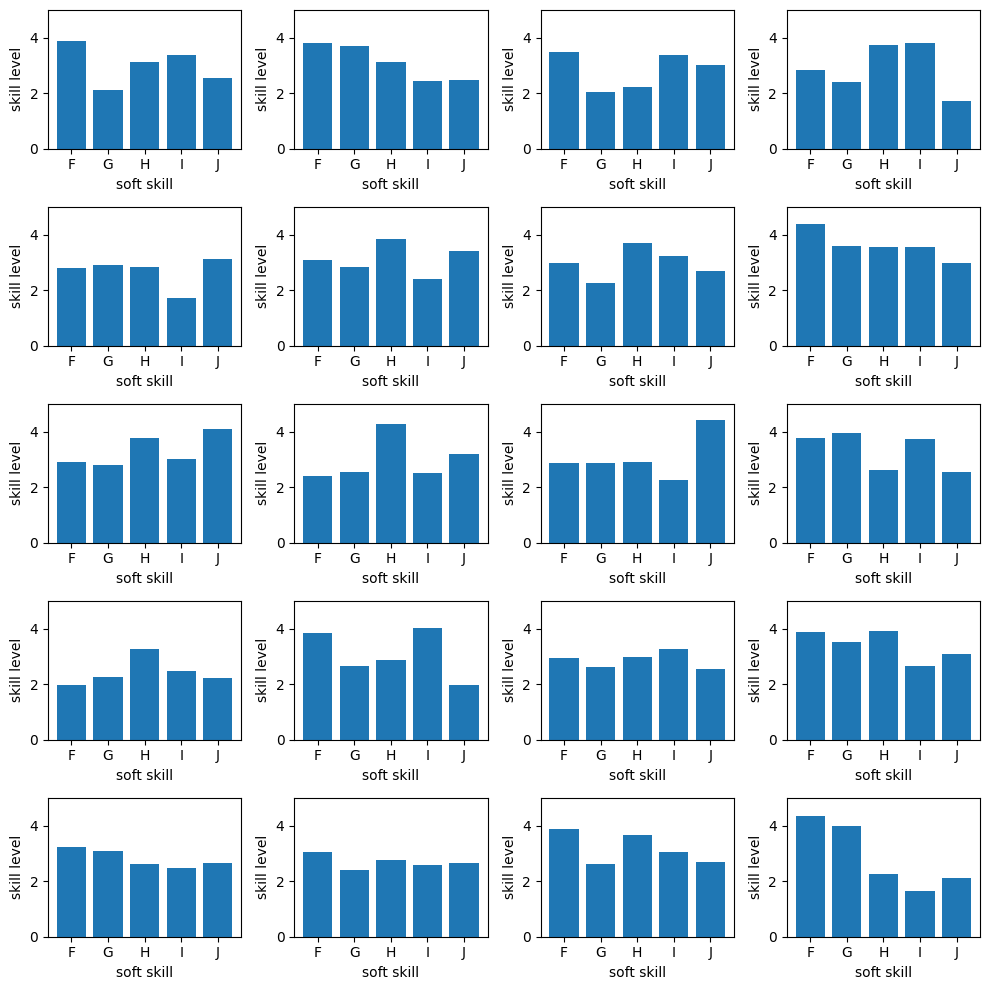

In [71]:
plt.figure(figsize=(10,10))
for wi, wid in enumerate(wids):
    
    plt.subplot(5,4,wi+1)
    plt.bar([i for i,j in enumerate(soft_skills)], state.state['worker_soft_skills'][wid])
    plt.xticks(ticks=[i for i,j in enumerate(soft_skills)], labels=soft_skills)
    plt.ylabel('skill level')
    plt.xlabel('soft skill')
    plt.ylim([0,5]);
    
plt.tight_layout()

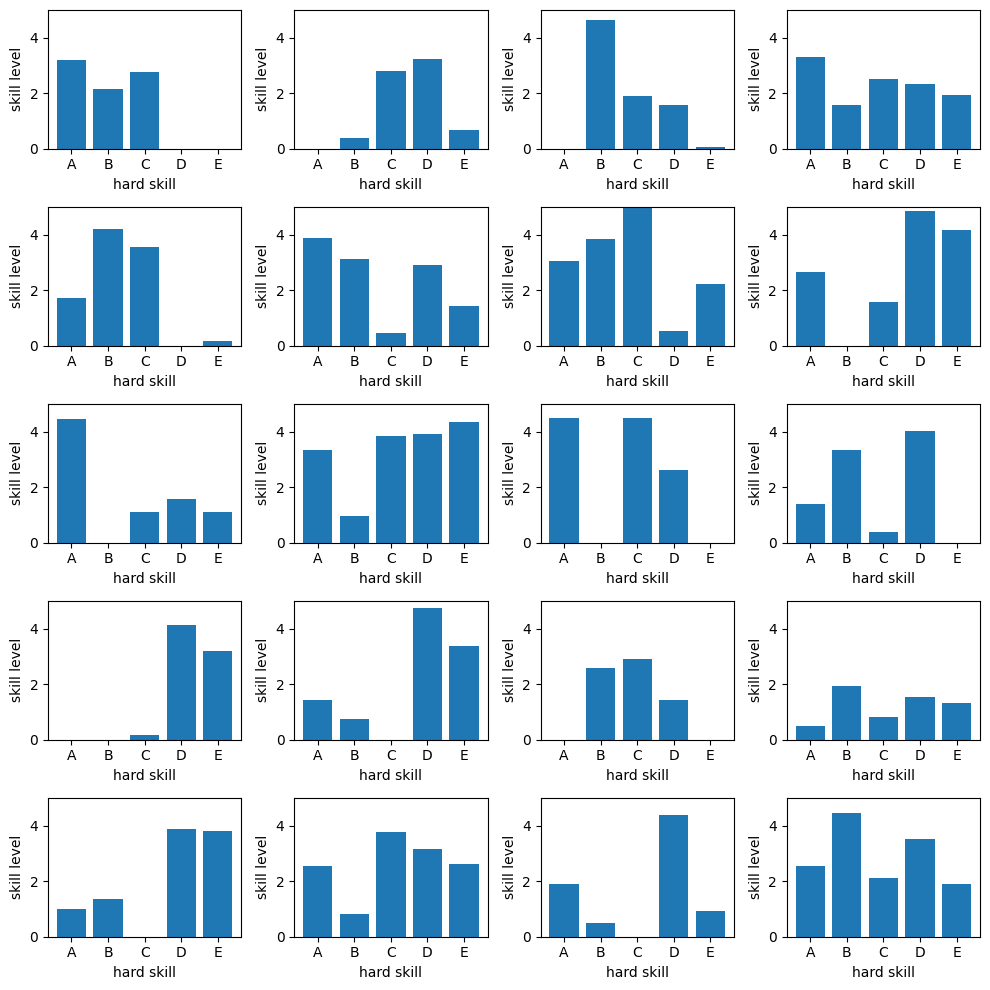

In [73]:
plt.figure(figsize=(10,10))
for wi, wid in enumerate(wids):
    
    plt.subplot(5,4,wi+1)
    plt.bar([i for i,j in enumerate(hard_skills)], state.state['worker_hard_skills'][wid])
    plt.xticks(ticks=[i for i,j in enumerate(hard_skills)], labels=hard_skills)
    plt.ylabel('skill level')
    plt.xlabel('hard skill')
    plt.ylim([0,5]);
    
plt.tight_layout()

#### We also check the prject required creativity distribution across the dataset:

In [77]:
pc = [
    load_state('../test_data/dataset_1/state_%d.pickle' % si).state['project_required_creativity']
    for si in range(100)
]

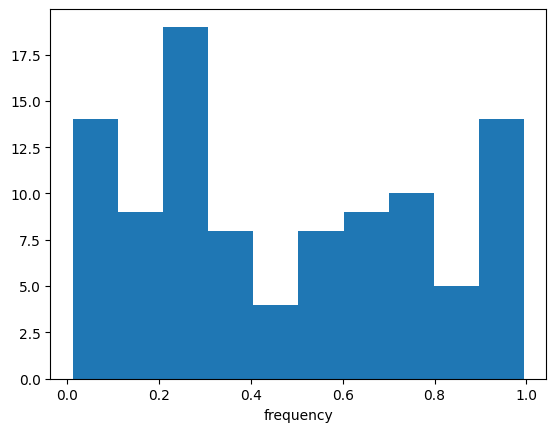

In [83]:
plt.hist(pc);
plt.xlabel('required creativity')
plt.xlabel('frequency');

In [84]:
state.state.keys()

dict_keys(['project_skill_levels', 'project_skill_units', 'project_risk', 'project_required_creativity', 'project_budget', 'worker_hard_skills', 'worker_soft_skills', 'worker_primary_secondary_hard_skills', 'worker_hard_skill_assignments', 'worker_hard_skill_mask', 'worker_availability', 'worker_prior_assignments', 'worker_department_id', 'worker_momentum', 'department_available_units', 'department_size', 'departmental_workload', 'social_network'])